In [12]:
#################################
#
# K - MEANS CLUSTERING
#
#################################
#
# Partition data into k-sets so that all points are closest to their assigned centroid in squared Euclidean distance, everything else is interpretation of these sets
# Its not -> probabilistic or representation learning or density estimation
# k-means assumes -> euclidean distance is similarity, clusters are roughly isotropic/spherical and convex, hve similar variance in their data, mean is a good representative 
# Clusters form voronoi cells
# Decision boundaries are perpendicular bisectors
# Density is ignored , rotating or scaling data breaks it, elongated clusters fail
# k-means assumes clusters are balls in Euclidean space and optimizes compactness, not meaning.
#
# Given data matrix X belongs to R (samples x features) and chosen k
# We want centroids centr_1,...,centr_k such that sum_i ||x_i - centr_{c(i)}||^2 is minimized
# This is a non-convex optimization -> solved by alternating minimization (coordinate descent)
#
# Algorithm 
# Initialization -> randomly choose k data points as initial centroids
# Assignment step -> assign each point to the nearest centroid (argmin Euclidean distance)
# Update step -> recompute each centroid as the mean of assigned points
# Repeat until centroids converge or max iterations reached
#
# This implementation stores (labels, centroids) at each iteration for animation
# Optimizes compactness (intra-cluster variance), not semantic meaning
#
# Limitations
# Sensitive to initialization and scaling of features
# Fails on elongated, non-convex, or varying-density clusters
# Rotations or anisotropic scaling can change results
# Guarantees only a local minimum of the objective

In [13]:
import numpy as np
import matplotlib.pyplot as plt 
rng= np.random.default_rng(1)
def k_means(X,k,max_iter=1000,tol=1e-6):
    centroids = X[np.random.choice(len(X),k,replace=False)]
    for _ in range(max_iter):
        distances = np.sqrt(((X[:,np.newaxis]-centroids)**2).sum(axis=2))
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([X[labels==i].mean(axis=0) for i in range(k)]) 
        if np.allclose(centroids,new_centroids,rtol=tol):
            break
        centroids = new_centroids
    return labels,centroids
        

######################### K-Means ########################################

k : 3

Final centroids:
[[-1.88199021 -2.00093768]
 [ 1.93922821  1.93858656]
 [ 2.06386993 -1.92668296]]

Cluster sizes: 
[101 103  96]



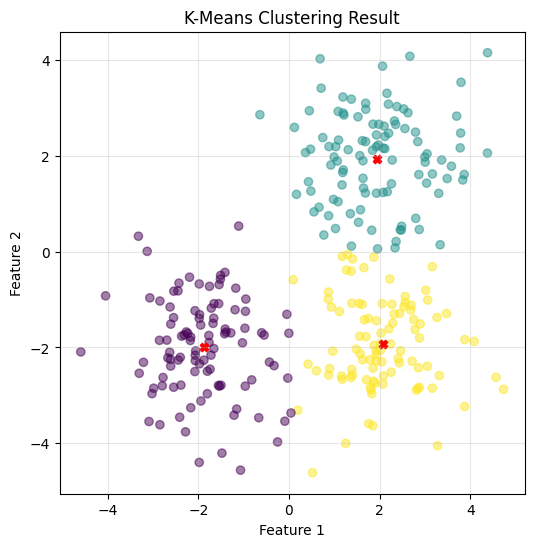

In [14]:
X = np.vstack([np.random.randn(100, 2) + [2, 2],
               np.random.randn(100, 2) + [-2, -2],
               np.random.randn(100, 2) + [2, -2]])
k = 3
labels_means, centroids= k_means(X, k)
print("######################### K-Means ########################################")
print()
print(f"k : {k}")
print()
print(f"Final centroids:\n{centroids}")
print()
print(f"Cluster sizes: \n{np.bincount(labels_means)}")
print()
plt.figure(figsize=(6, 6))
plt.scatter(X[:,0], X[:,1], c=labels_means, cmap='viridis',alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X')
plt.title('K-Means Clustering Result')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

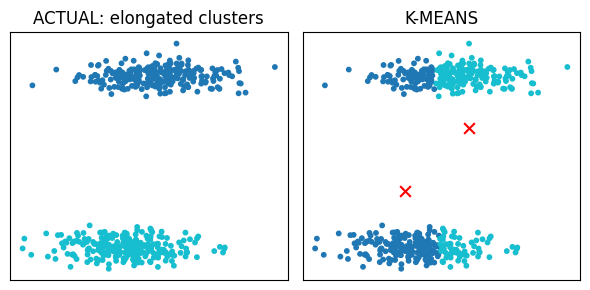

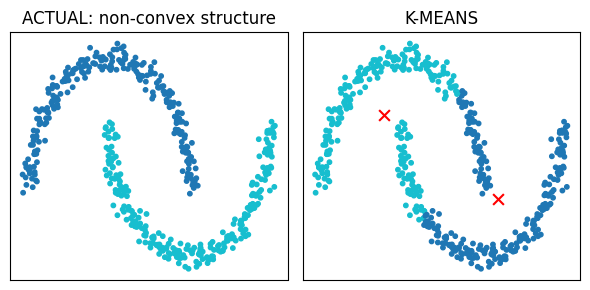

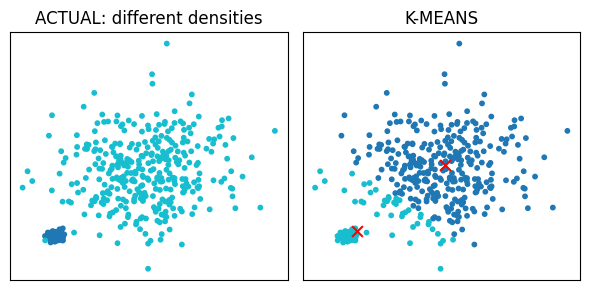

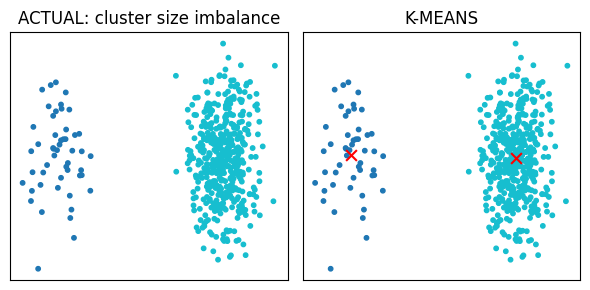

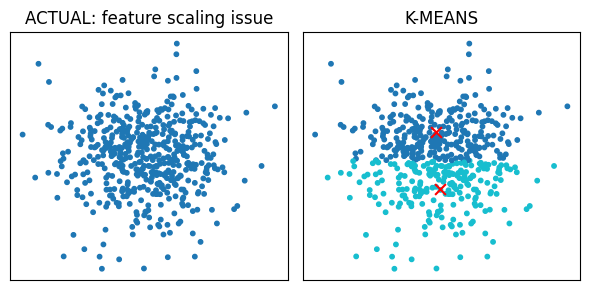

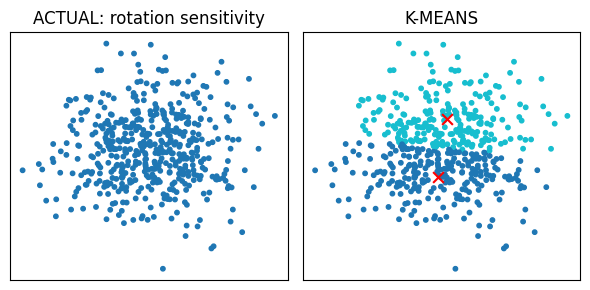

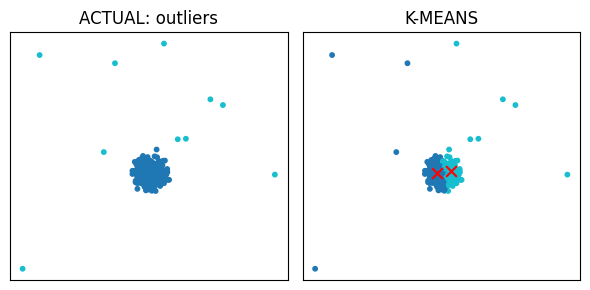

In [15]:
np.random.seed(42)
n_samples = 500

# ###################################
# 1. ELONGATED / ANISOTROPIC CLUSTERS
# fails spherical + isotropic assumption
# ###################################
X_elongated = np.vstack([
    np.random.randn(n_samples//2, 2) @ np.array([[5, 0], [0, 0.2]]) + [2, 2],
    np.random.randn(n_samples//2, 2) @ np.array([[5, 0], [0, 0.2]]) + [-2, -2]
])
y_elongated = np.hstack([
    np.zeros(n_samples//2, dtype=int),
    np.ones(n_samples//2, dtype=int)
])

# ###################################
# 2. NON-CONVEX CLUSTERS (TWO MOONS)
# fails convex / Voronoi separability
# ###################################
theta = np.linspace(0, np.pi, n_samples//2)
moon1 = np.c_[np.cos(theta), np.sin(theta)]
moon2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta) - 0.5]
X_nonconvex = np.vstack([moon1, moon2]) + 0.05 * np.random.randn(n_samples, 2)
y_nonconvex = np.hstack([
    np.zeros(n_samples//2, dtype=int),
    np.ones(n_samples//2, dtype=int)
])

# ###################################
# 3. DIFFERENT DENSITIES
# fails equal variance / density assumption
# ###################################
dense = 0.2 * np.random.randn(n_samples//3, 2) + [0, 0]
sparse = 2.5 * np.random.randn(2*n_samples//3, 2) + [5, 5]
X_density = np.vstack([dense, sparse])
y_density = np.hstack([
    np.zeros(n_samples//3, dtype=int),
    np.ones(2*n_samples//3, dtype=int)
])

# ###################################
# 4. DIFFERENT CLUSTER SIZES
# centroid placement biased toward large clusters
# ###################################
small = np.random.randn(50, 2) + [-5, 0]
large = np.random.randn(450, 2) + [5, 0]
X_size_imbalance = np.vstack([small, large])
y_size_imbalance = np.hstack([
    np.zeros(50, dtype=int),
    np.ones(450, dtype=int)
])

# ###################################
# 5. SCALE SENSITIVITY
# Euclidean distance dominated by large-variance feature
# ###################################
X_scaled = np.random.randn(n_samples, 2)
X_scaled[:, 1] *= 100
y_scaled = np.zeros(n_samples, dtype=int)

# ###################################
# 6. ROTATION SENSITIVITY
# same structure, rotated geometry
# ###################################
X_base = np.random.randn(n_samples, 2)
R = np.array([[0.7, -0.7],
              [0.7,  0.7]])
X_rotated = X_base @ R
y_rotated = np.zeros(n_samples, dtype=int)

# ###################################
# 7. OUTLIERS
# mean is not robust
# ###################################
X_outliers = np.random.randn(n_samples, 2)
outliers = np.random.uniform(low=-20, high=20, size=(10, 2))
X_outliers = np.vstack([X_outliers, outliers])
y_outliers = np.hstack([
    np.zeros(n_samples, dtype=int),
    np.ones(10, dtype=int)
])


test_cases = [
    ("elongated clusters", X_elongated, y_elongated),
    ("non-convex structure", X_nonconvex, y_nonconvex),
    ("different densities", X_density, y_density),
    ("cluster size imbalance", X_size_imbalance, y_size_imbalance),
    ("feature scaling issue", X_scaled, y_scaled),
    ("rotation sensitivity", X_rotated, y_rotated),
    ("outliers", X_outliers, y_outliers),
]


k = 2

for name, X, y_true in test_cases:
    labels, centroids= k_means(X, k)

    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=10)
    ax[0].set_title(f"ACTUAL: {name}")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    ax[1].scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=10)
    ax[1].scatter(
        centroids[:, 0], centroids[:, 1],
        c="red", marker="x", s=60
    )
    ax[1].set_title("K-MEANS")
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    plt.tight_layout()
    plt.show()
